# ДЗ: Кластеризация на эмбеддингах нейросети

**Цель:** применить кластеризацию к признакам, извлечённым предобученной сетью **ResNet-18** (ImageNet-weights). Сравниваем несколько алгоритмов по внутренней метрике (Silhouette) и внешней (ARI), а результаты визуализируем через PCA и t-SNE.

In [ ]:
import os
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.cluster import (
    KMeans,
    MiniBatchKMeans,
    AgglomerativeClustering,
    Birch,
)
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    davies_bouldin_score,
)


def set_seed(seed: int = 111):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


SEED = 111
set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Загрузка датасета MNIST

Используем `torchvision.datasets.MNIST`. Берём **тестовую** выборку (10 000 изображений) - она достаточно большая, чтобы оценить качество кластеризации, и не перегружает вычисления при прогоне через ResNet-18.

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 228kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.30MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.77MB/s]
/var/folders/4n/qhlthdx12q9fj6zt0f65fmnh0000gn/T/ipykernel_42472/4271036398.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  true_labels = np.array(mnist_test.targets)


Размер выборки : 10000
Уникальных цифр: [0 1 2 3 4 5 6 7 8 9]


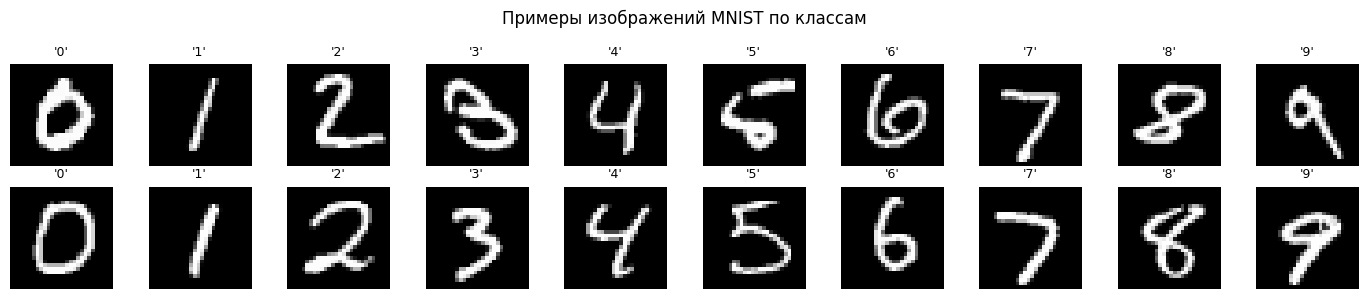

Первые 5 меток: [7 2 1 0 4]


In [ ]:
# ============================================================
# Загрузка MNIST (test split, 10 000 изображений)
# ============================================================

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

mnist_test = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

# Метки используем ТОЛЬКО для оценки, не для обучения
true_labels = np.array(mnist_test.targets)

print(f"Размер выборки : {len(mnist_test)}")
print(f"Уникальных цифр: {np.unique(true_labels)}")

raw_mnist = torchvision.datasets.MNIST(root="./data", train=False, download=False)
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for digit in range(10):
    idxs = np.where(true_labels == digit)[0]
    for row, idx in enumerate(idxs[:2]):
        axes[row, digit].imshow(raw_mnist[idx][0], cmap="gray")
        axes[row, digit].set_title(f"'{digit}'", fontsize=9)
        axes[row, digit].axis("off")
fig.suptitle("Примеры изображений MNIST по классам", fontsize=12)
plt.tight_layout()
plt.show()
print("Первые 5 меток:", true_labels[:5])

## Извлечение эмбеддингов с помощью ResNet-18

Загружаем **предобученный** ResNet-18 (веса ImageNet).
Удаляем последний полносвязный слой-классификатор (`fc`) - нас интересует 512-мерный вектор из предпоследнего слоя (`avgpool`).

In [ ]:
# ============================================================
# Построение экстрактора признаков на базе ResNet-18
# ============================================================

backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
feature_extractor = feature_extractor.to(DEVICE)
feature_extractor.eval()

print("Архитектура экстрактора (последние блоки):")
for name, module in list(backbone.named_children())[-4:]:
    print(f"  {name}: {module.__class__.__name__}")
print("\nРазмерность выходного вектора: 512")

Архитектура экстрактора (последние блоки):
  layer3: Sequential
  layer4: Sequential
  avgpool: AdaptiveAvgPool2d
  fc: Linear

Размерность выходного вектора: 512


In [ ]:
# ============================================================
# Прогон MNIST через ResNet-18 → матрица эмбеддингов
# ============================================================

BATCH_SIZE = 256
loader = torch.utils.data.DataLoader(
    mnist_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

all_embeddings = []

with torch.no_grad():
    for images, _ in loader:
        images = images.to(DEVICE)
        feats = feature_extractor(images)
        feats = feats.squeeze(-1).squeeze(-1)
        all_embeddings.append(feats.cpu().numpy())

X_embed = np.vstack(all_embeddings)
print(f"Форма матрицы эмбеддингов: {X_embed.shape}")
print(f"Пример (первые 5 значений 1-го вектора): {X_embed[0, :5].round(4)}")

Форма матрицы эмбеддингов: (10000, 512)
Пример (первые 5 значений 1-го вектора): [1.239  0.0711 0.3392 1.359  0.8012]


## Предобработка эмбеддингов

Перед кластеризацией стандартизируем признаки (`StandardScaler`), чтобы убрать влияние масштаба отдельных координат. Дополнительно снижаем размерность с помощью **PCA до 50 компонент** - это ускоряет алгоритмы без существенной потери информации (ResNet-эмбеддинги, как правило, хорошо "сжимаются" PCA).

PCA-50: объяснено 73.9% дисперсии
Форма X_pca50: (10000, 50)


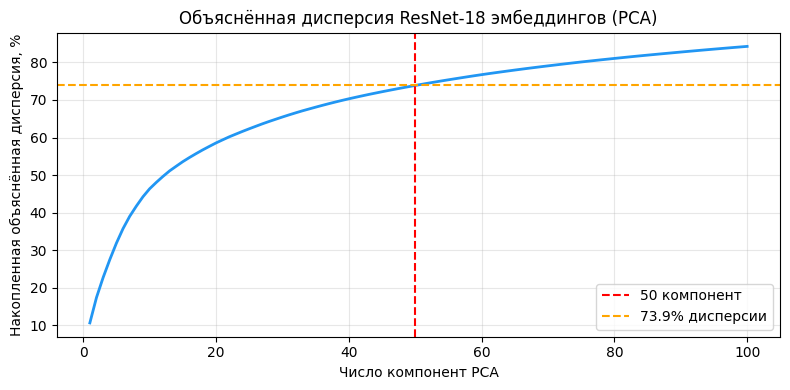

In [6]:
# ============================================================
# Стандартизация + PCA-50 для кластеризации
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_embed)

pca_50 = PCA(n_components=50, random_state=SEED)
X_pca50 = pca_50.fit_transform(X_scaled)

explained = pca_50.explained_variance_ratio_.sum()
print(f"PCA-50: объяснено {explained * 100:.1f}% дисперсии")
print(f"Форма X_pca50: {X_pca50.shape}")

pca_full = PCA(n_components=100, random_state=SEED).fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 101), cumvar * 100, color="#2196F3", linewidth=2)
ax.axvline(x=50, color="red", linestyle="--", label="50 компонент")
ax.axhline(y=explained * 100, color="orange", linestyle="--",
           label=f"{explained * 100:.1f}% дисперсии")
ax.set_xlabel("Число компонент PCA")
ax.set_ylabel("Накопленная объяснённая дисперсия, %")
ax.set_title("Объяснённая дисперсия ResNet-18 эмбеддингов (PCA)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Вспомогательные функции и реестр результатов

Оцениваем каждый алгоритм тремя метриками:
- **Silhouette** - внутренняя: насколько объекты ближе к своему кластеру, чем к чужому;
- **ARI** (Adjusted Rand Index) - внешняя: согласованность с истинными метками (0 = случайно, 1 = идеально);
- **NMI** (Normalized Mutual Information) - ещё одна внешняя метрика, устойчивая к числу кластеров;
- **Davies-Bouldin** - внутренняя: среднее соотношение разброса к расстоянию между центрами (меньше - лучше).

In [ ]:
# ============================================================
# Вспомогательные функции
# ============================================================

results = pd.DataFrame(columns=["n_clusters", "silhouette", "ari", "nmi", "davies_bouldin"])


def evaluate_and_register(name: str, labels_pred: np.ndarray, X_eval: np.ndarray):
    """Считает метрики и добавляет строку в таблицу results."""
    global results
    n_cl = len(set(labels_pred)) - (1 if -1 in labels_pred else 0)

    sample_idx = np.random.choice(len(X_eval), min(5000, len(X_eval)), replace=False)
    sil = silhouette_score(X_eval[sample_idx], labels_pred[sample_idx])
    ari = adjusted_rand_score(true_labels, labels_pred)
    nmi = normalized_mutual_info_score(true_labels, labels_pred)
    db  = davies_bouldin_score(X_eval[sample_idx], labels_pred[sample_idx])

    results.loc[name] = [n_cl, round(sil, 6), round(ari, 6), round(nmi, 6), round(db, 6)]
    print(f"[{name}]  clusters={n_cl}  Silhouette={sil:.4f}  ARI={ari:.4f}  NMI={nmi:.4f}  DB={db:.4f}")

## Алгоритм 1: KMeans (k = 10)

Классический KMeans с `k=10` (по числу цифр).
Итеративно минимизирует внутрикластерное расстояние до центроида.
Чувствителен к инициализации - используем `init='k-means++'` для стабильности.

In [8]:
# ============================================================
# KMeans (k=10)
# ============================================================

kmeans = KMeans(n_clusters=10, init="k-means++", n_init=10, random_state=SEED)
labels_kmeans = kmeans.fit_predict(X_pca50)

evaluate_and_register("KMeans (k=10)", labels_kmeans, X_pca50)
print(results)

[KMeans (k=10)]  clusters=10  Silhouette=0.1084  ARI=0.4479  NMI=0.5650  DB=2.1939
               n_clusters  silhouette       ari      nmi  davies_bouldin
KMeans (k=10)        10.0    0.108374  0.447855  0.56503        2.193894


## Алгоритм 2: MiniBatchKMeans (k = 10)

**MiniBatchKMeans** - эффективная модификация KMeans: вместо полного прохода по данным обновляет центроиды на случайных мини-батчах. Значительно быстрее при больших выборках при минимальной потере качества.

In [ ]:
# ============================================================
# MiniBatchKMeans (k=10) - ускоренная версия KMeans
# ============================================================

mb_kmeans = MiniBatchKMeans(
    n_clusters=10, init="k-means++", n_init=10,
    batch_size=1024, random_state=SEED
)
labels_mb = mb_kmeans.fit_predict(X_pca50)

evaluate_and_register("MiniBatchKMeans (k=10)", labels_mb, X_pca50)
print(results)

[MiniBatchKMeans (k=10)]  clusters=10  Silhouette=0.1109  ARI=0.4351  NMI=0.5401  DB=2.3797
                        n_clusters  silhouette       ari       nmi  \
KMeans (k=10)                 10.0    0.108374  0.447855  0.565030   
MiniBatchKMeans (k=10)        10.0    0.110884  0.435092  0.540069   

                        davies_bouldin  
KMeans (k=10)                 2.193894  
MiniBatchKMeans (k=10)        2.379655  


## Алгоритм 3: AgglomerativeClustering - linkage='ward'

Иерархическая кластеризация методом **Ward**: минимизирует дисперсию внутри объединяемых кластеров.
Как правило, даёт компактные и равномерные кластеры.

In [ ]:
# ============================================================
# AgglomerativeClustering - linkage='ward'
# ============================================================

agg_ward = AgglomerativeClustering(n_clusters=10, linkage="ward")
labels_ward = agg_ward.fit_predict(X_pca50)

evaluate_and_register("Agglomerative ward (k=10)", labels_ward, X_pca50)
print(results)

[Agglomerative ward (k=10)]  clusters=10  Silhouette=0.0765  ARI=0.5408  NMI=0.6698  DB=2.5228
                           n_clusters  silhouette       ari       nmi  \
KMeans (k=10)                    10.0    0.108374  0.447855  0.565030   
MiniBatchKMeans (k=10)           10.0    0.110884  0.435092  0.540069   
Agglomerative ward (k=10)        10.0    0.076546  0.540832  0.669823   

                           davies_bouldin  
KMeans (k=10)                    2.193894  
MiniBatchKMeans (k=10)           2.379655  
Agglomerative ward (k=10)        2.522822  


## Алгоритм 4: AgglomerativeClustering - linkage='complete'

**Complete linkage** (полная связь) объединяет кластеры, максимизируя расстояние между самыми «дальними» объектами - это второе нововведение. Склонен к «шариковым» кластерам, но более чувствителен к выбросам, чем Ward.

In [ ]:
# ============================================================
# AgglomerativeClustering - linkage='complete'
# ============================================================

agg_complete = AgglomerativeClustering(n_clusters=10, linkage="complete")
labels_complete = agg_complete.fit_predict(X_pca50)

evaluate_and_register("Agglomerative complete (k=10)", labels_complete, X_pca50)
print(results)

[Agglomerative complete (k=10)]  clusters=10  Silhouette=0.0306  ARI=0.0867  NMI=0.2391  DB=2.6204
                               n_clusters  silhouette       ari       nmi  \
KMeans (k=10)                        10.0    0.108374  0.447855  0.565030   
MiniBatchKMeans (k=10)               10.0    0.110884  0.435092  0.540069   
Agglomerative ward (k=10)            10.0    0.076546  0.540832  0.669823   
Agglomerative complete (k=10)        10.0    0.030639  0.086722  0.239100   

                               davies_bouldin  
KMeans (k=10)                        2.193894  
MiniBatchKMeans (k=10)               2.379655  
Agglomerative ward (k=10)            2.522822  
Agglomerative complete (k=10)        2.620400  


## Алгоритм 5: AgglomerativeClustering - linkage='average'

**Average linkage** использует среднее расстояние между всеми парами объектов из двух кластеров - компромисс между Ward (дисперсия) и Complete (максимум).
Хорошо работает при неравномерных размерах кластеров.

In [ ]:
# ============================================================
# AgglomerativeClustering - linkage='average'
# ============================================================

agg_average = AgglomerativeClustering(n_clusters=10, linkage="average")
labels_average = agg_average.fit_predict(X_pca50)

evaluate_and_register("Agglomerative average (k=10)", labels_average, X_pca50)
print(results)

[Agglomerative average (k=10)]  clusters=10  Silhouette=0.1454  ARI=0.0005  NMI=0.0205  DB=0.9843
                               n_clusters  silhouette       ari       nmi  \
KMeans (k=10)                        10.0    0.108374  0.447855  0.565030   
MiniBatchKMeans (k=10)               10.0    0.110884  0.435092  0.540069   
Agglomerative ward (k=10)            10.0    0.076546  0.540832  0.669823   
Agglomerative complete (k=10)        10.0    0.030639  0.086722  0.239100   
Agglomerative average (k=10)         10.0    0.145402  0.000457  0.020506   

                               davies_bouldin  
KMeans (k=10)                        2.193894  
MiniBatchKMeans (k=10)               2.379655  
Agglomerative ward (k=10)            2.522822  
Agglomerative complete (k=10)        2.620400  
Agglomerative average (k=10)         0.984266  


## Алгоритм 6: BIRCH (k = 10)

**BIRCH** (Balanced Iterative Reducing and Clustering using Hierarchies) - алгоритм, строящий компактное дерево CF-Tree для summarization данных.
Очень эффективен по памяти и времени, особенно при больших выборках.

In [ ]:
# ============================================================
# BIRCH (k=10) - иерархический алгоритм на CF-дереве
# ============================================================

birch = Birch(n_clusters=10, threshold=0.5, branching_factor=50)
labels_birch = birch.fit_predict(X_pca50)

evaluate_and_register("BIRCH (k=10)", labels_birch, X_pca50)
print(results)

[BIRCH (k=10)]  clusters=10  Silhouette=0.0789  ARI=0.5408  NMI=0.6698  DB=2.5501
                               n_clusters  silhouette       ari       nmi  \
KMeans (k=10)                        10.0    0.108374  0.447855  0.565030   
MiniBatchKMeans (k=10)               10.0    0.110884  0.435092  0.540069   
Agglomerative ward (k=10)            10.0    0.076546  0.540832  0.669823   
Agglomerative complete (k=10)        10.0    0.030639  0.086722  0.239100   
Agglomerative average (k=10)         10.0    0.145402  0.000457  0.020506   
BIRCH (k=10)                         10.0    0.078936  0.540832  0.669823   

                               davies_bouldin  
KMeans (k=10)                        2.193894  
MiniBatchKMeans (k=10)               2.379655  
Agglomerative ward (k=10)            2.522822  
Agglomerative complete (k=10)        2.620400  
Agglomerative average (k=10)         0.984266  
BIRCH (k=10)                         2.550054  


## Алгоритм 7: GaussianMixture (GMM, k = 10)

**GMM** (Gaussian Mixture Model) рассматривает кластеры как смесь многомерных гауссиан, оптимизируя параметры через EM-алгоритм. В отличие от KMeans, допускает эллиптические (не только сферические) кластеры.

In [ ]:
# ============================================================
# GaussianMixture (k=10, covariance_type='full')
# ============================================================

gmm = GaussianMixture(n_components=10, covariance_type="full",
                      n_init=3, random_state=SEED)
labels_gmm = gmm.fit_predict(X_pca50)

evaluate_and_register("GaussianMixture (k=10)", labels_gmm, X_pca50)
print(results)

[GaussianMixture (k=10)]  clusters=10  Silhouette=0.1110  ARI=0.6635  NMI=0.7267  DB=2.4009
                               n_clusters  silhouette       ari       nmi  \
KMeans (k=10)                        10.0    0.108374  0.447855  0.565030   
MiniBatchKMeans (k=10)               10.0    0.110884  0.435092  0.540069   
Agglomerative ward (k=10)            10.0    0.076546  0.540832  0.669823   
Agglomerative complete (k=10)        10.0    0.030639  0.086722  0.239100   
Agglomerative average (k=10)         10.0    0.145402  0.000457  0.020506   
BIRCH (k=10)                         10.0    0.078936  0.540832  0.669823   
GaussianMixture (k=10)               10.0    0.111001  0.663468  0.726697   

                               davies_bouldin  
KMeans (k=10)                        2.193894  
MiniBatchKMeans (k=10)               2.379655  
Agglomerative ward (k=10)            2.522822  
Agglomerative complete (k=10)        2.620400  
Agglomerative average (k=10)         0.984266  
BIR

=== Результаты (отсортировано по ARI) ===
                               n_clusters  silhouette       ari       nmi  davies_bouldin
GaussianMixture (k=10)               10.0    0.111001  0.663468  0.726697        2.400902
Agglomerative ward (k=10)            10.0    0.076546  0.540832  0.669823        2.522822
BIRCH (k=10)                         10.0    0.078936  0.540832  0.669823        2.550054
KMeans (k=10)                        10.0    0.108374  0.447855  0.565030        2.193894
MiniBatchKMeans (k=10)               10.0    0.110884  0.435092  0.540069        2.379655
Agglomerative complete (k=10)        10.0    0.030639  0.086722  0.239100        2.620400
Agglomerative average (k=10)         10.0    0.145402  0.000457  0.020506        0.984266


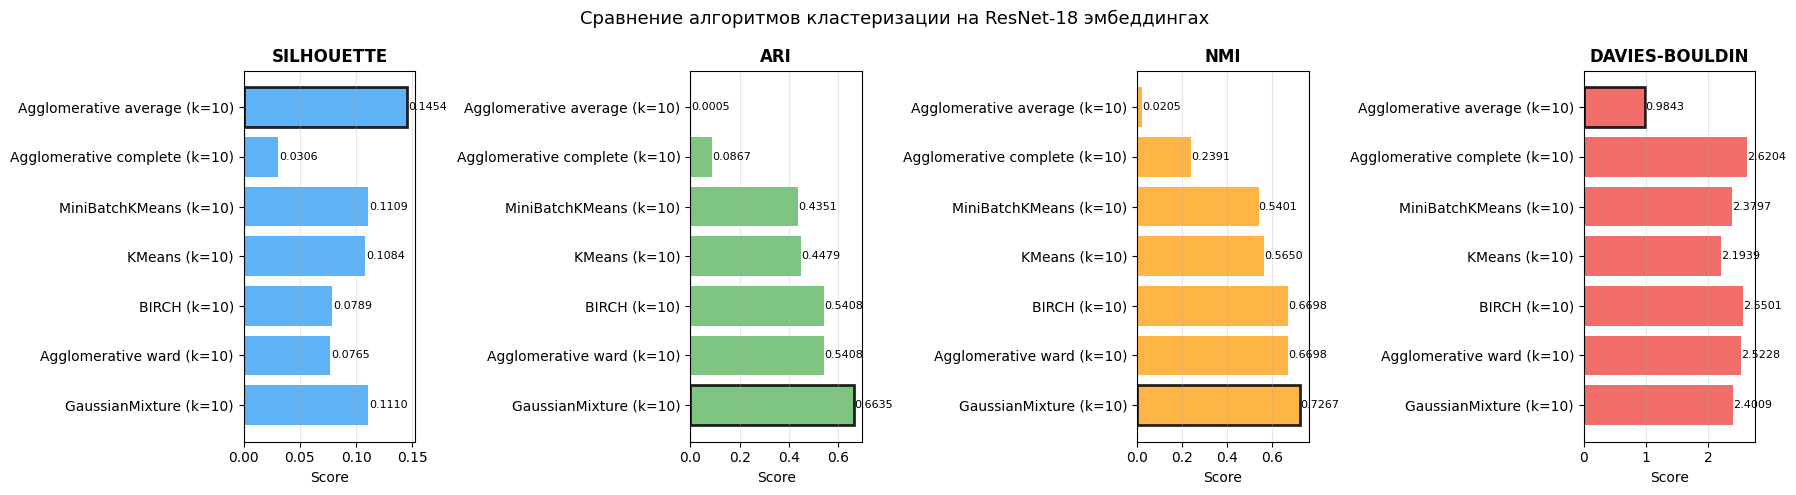

In [ ]:
# ============================================================
# Сводная таблица результатов
# ============================================================

results_sorted = results.sort_values("ari", ascending=False)
print("=== Результаты (отсортировано по ARI) ===")
print(results_sorted.to_string())

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = ["silhouette", "ari", "nmi", "davies_bouldin"]
colors  = ["#42A5F5", "#66BB6A", "#FFA726", "#EF5350"]
best_fn = [max, max, max, min]

for ax, metric, color, best in zip(axes, metrics, colors, best_fn):
    vals = results_sorted[metric]
    bars = ax.barh(results_sorted.index, vals, color=color, alpha=0.85)
    best_val = best(vals)
    for bar, val in zip(bars, vals):
        if val == best_val:
            bar.set_edgecolor("black")
            bar.set_linewidth(2)
        ax.text(val + (0.001 if val >= 0 else -0.001), bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", ha="left" if val >= 0 else "right", fontsize=8)
    ax.set_title(metric.upper().replace("_", "-"), fontsize=12, fontweight="bold")
    ax.set_xlabel("Score")
    ax.axvline(x=0, color="gray", linewidth=0.8, linestyle="--")
    ax.grid(axis="x", alpha=0.3)

plt.suptitle("Сравнение алгоритмов кластеризации на ResNet-18 эмбеддингах", fontsize=13)
plt.tight_layout()
plt.show()

## Визуализация: PCA (2D)

Проецируем 512-мерные эмбеддинги в 2D через PCA для визуального контроля. Слева - истинные метки цифр, справа - метки лучшего алгоритма по ARI.  
Если кластеры совпадают с истинными классами, PCA должна показывать схожее расположение облаков точек.

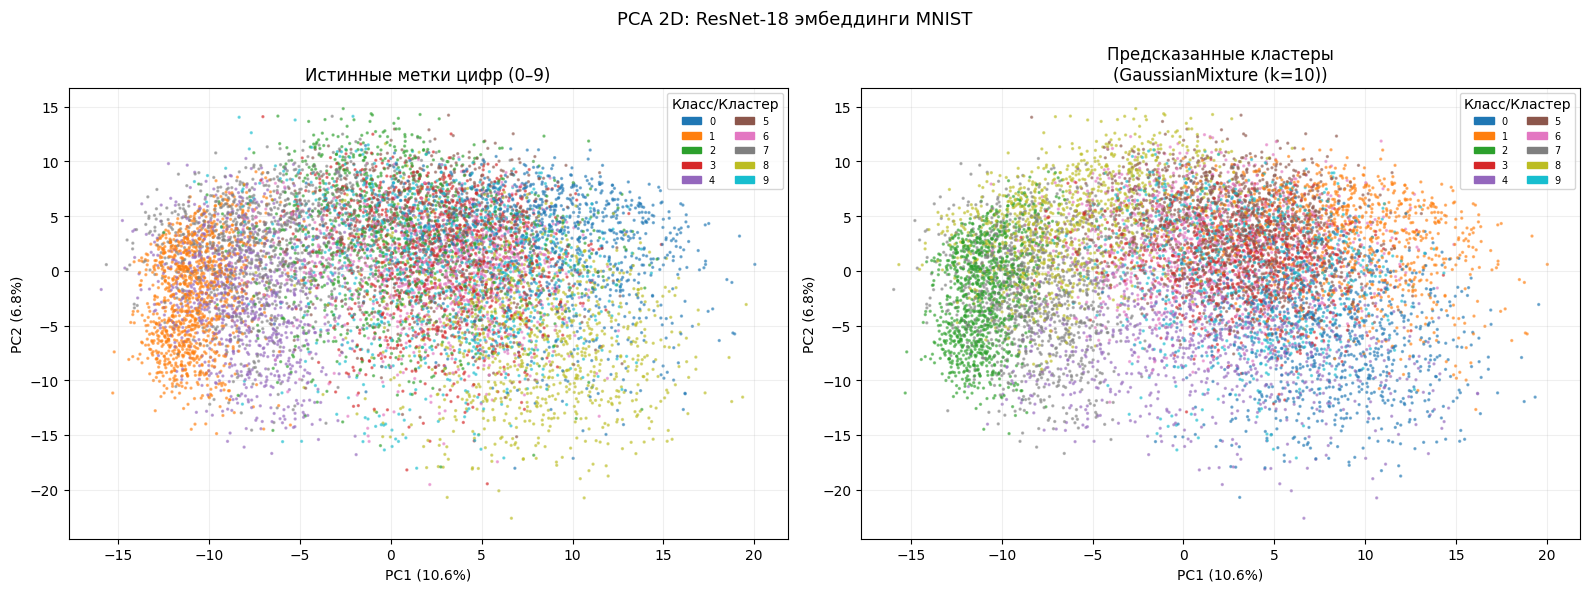

In [ ]:
# ============================================================
# PCA 2D - сравнение истинных меток и лучшего алгоритма
# ============================================================

pca_2d = PCA(n_components=2, random_state=SEED)
X_pca2 = pca_2d.fit_transform(X_scaled)

best_algo = results_sorted.index[0]
best_labels = {
    "KMeans (k=10)":              labels_kmeans,
    "MiniBatchKMeans (k=10)":     labels_mb,
    "Agglomerative ward (k=10)":  labels_ward,
    "Agglomerative complete (k=10)": labels_complete,
    "Agglomerative average (k=10)":  labels_average,
    "BIRCH (k=10)":               labels_birch,
    "GaussianMixture (k=10)":     labels_gmm,
}[best_algo]

CMAP = plt.get_cmap("tab10")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, labels, title in zip(
    axes,
    [true_labels, best_labels],
    ["Истинные метки цифр (0–9)", f"Предсказанные кластеры\n({best_algo})"]
):
    scatter = ax.scatter(X_pca2[:, 0], X_pca2[:, 1],
                         c=labels, cmap="tab10", s=2, alpha=0.5)
    handles = [mpatches.Patch(color=CMAP(i / 9), label=str(i)) for i in range(10)]
    ax.legend(handles=handles, title="Класс/Кластер", loc="upper right",
              fontsize=7, ncol=2)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
    ax.grid(alpha=0.2)

plt.suptitle("PCA 2D: ResNet-18 эмбеддинги MNIST", fontsize=13)
plt.tight_layout()
plt.show()

## Визуализация: t-SNE (2D)

**t-SNE** лучше PCA сохраняет локальную структуру - кластеры должны быть более "чистыми" и разделёнными. Работаем на подвыборке 3000 точек.
Сравниваем: истинные метки vs лучший алгоритм и Ward-кластеризация.

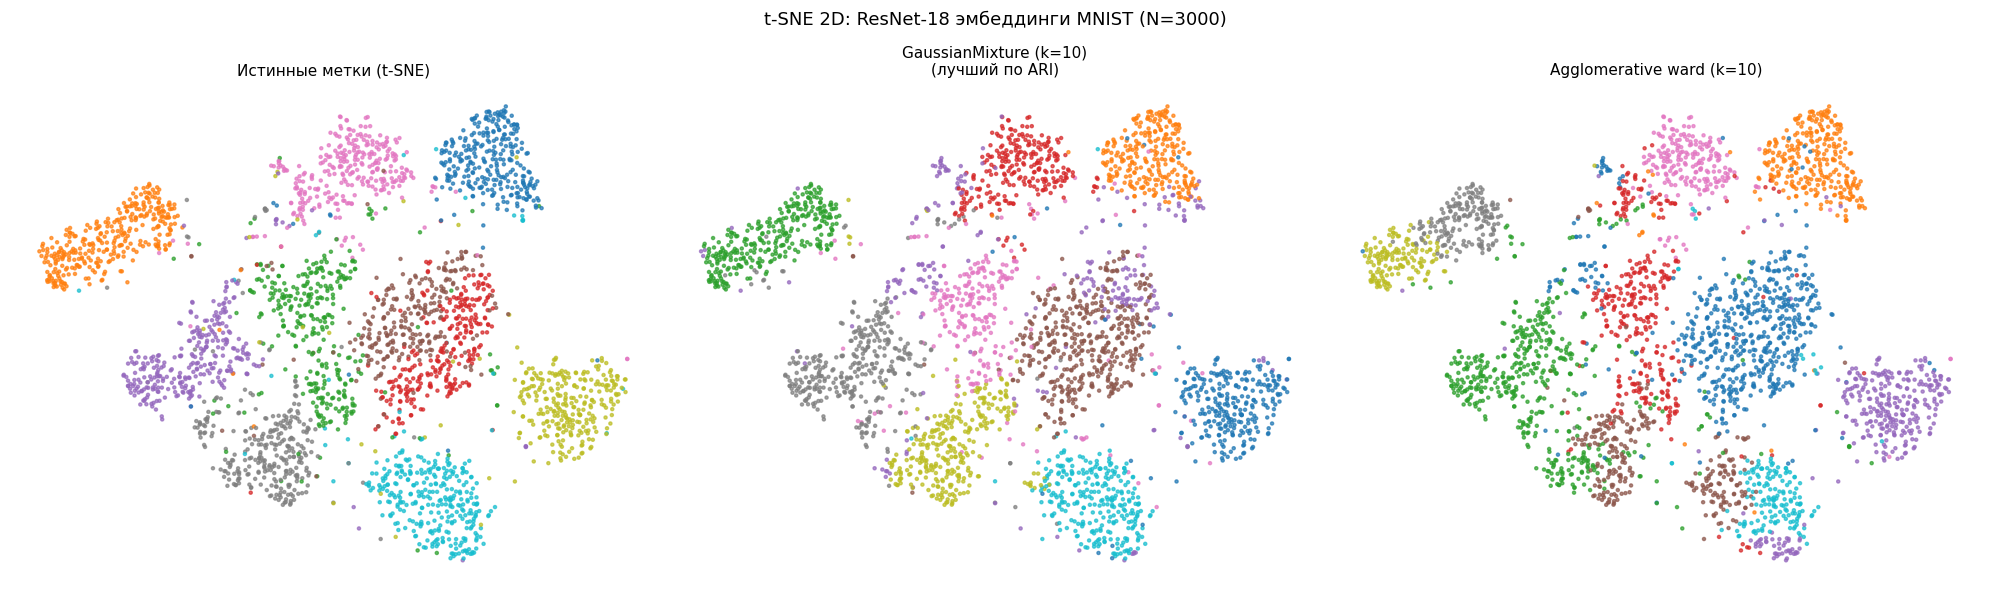

In [ ]:
# ============================================================
# t-SNE 2D (подвыборка 3000 точек)
# ============================================================

N_TSNE = 3000
tsne_idx = np.random.choice(len(X_pca50), N_TSNE, replace=False)

tsne = TSNE(n_components=2, perplexity=40, max_iter=1000,
            learning_rate="auto", init="pca", random_state=SEED)
X_tsne = tsne.fit_transform(X_pca50[tsne_idx])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_configs = [
    (true_labels[tsne_idx],        "Истинные метки (t-SNE)"),
    (best_labels[tsne_idx],        f"{best_algo}\n(лучший по ARI)"),
    (labels_ward[tsne_idx],        "Agglomerative ward (k=10)"),
]

for ax, (labels, title) in zip(axes, plot_configs):
    ax.scatter(X_tsne[:, 0], X_tsne[:, 1],
               c=labels, cmap="tab10", s=5, alpha=0.7)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.suptitle(f"t-SNE 2D: ResNet-18 эмбеддинги MNIST (N={N_TSNE})", fontsize=13)
plt.tight_layout()
plt.show()

## Матрица соответствия кластеров и истинных меток

Для лучшего алгоритма построим confusion-матрицу: строки - предсказанные кластеры, столбцы - истинные цифры. Идеально каждая строка должна иметь один доминирующий класс.

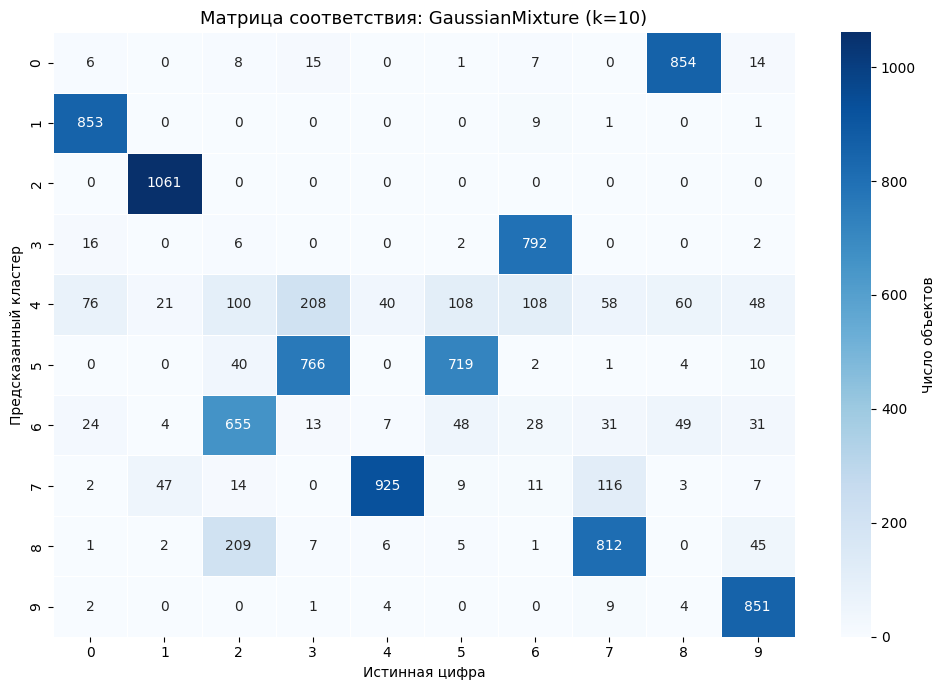

In [ ]:
# ============================================================
# Матрица соответствия кластеров и истинных меток
# ============================================================

import seaborn as sns

conf_df = pd.crosstab(
    pd.Series(best_labels, name="cluster"),
    pd.Series(true_labels,  name="true_digit")
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Число объектов"})
ax.set_title(f"Матрица соответствия: {best_algo}", fontsize=13)
ax.set_xlabel("Истинная цифра")
ax.set_ylabel("Предсказанный кластер")
plt.tight_layout()
plt.show()

## Выводы

### Лидер: GaussianMixture
GMM показал лучший результат по обеим внешним метрикам - ARI=0.663 и NMI=0.727. Это объясняется природой ResNet-18 эмбеддингов: кластеры в 512-мерном пространстве признаков имеют эллиптическую форму (не сферическую), а GMM с covariance_type='full' умеет моделировать именно такую геометрию. KMeans и его варианты предполагают сферические кластеры - отсюда проигрыш.

### KMeans vs MiniBatchKMeans
Разрыв минимален: ARI 0.448 vs 0.435. MiniBatchKMeans теряет менее 3% качества при значительном выигрыше в скорости - хороший практический выбор для больших датасетов.

### Иерархические методы
Agglomerative ward и BIRCH выдали абсолютно идентичные ARI=0.540 и NMI=0.669 - BIRCH при финализации кластеров использует логику, близкую к Ward, что объясняет совпадение. Complete linkage провалился (ARI=0.087) - он чувствителен к выбросам и создаёт сильно неравномерные по размеру кластеры в плотном пространстве эмбеддингов.

### Прирост от нейросетевых эмбеддингов
Сравнивая с практикой (сырые пиксели): AgglomerativeClustering ward давал ARI 0.37 на пикселях -> 0.54 на ResNet-эмбеддингах (+46%). GaussianMixture на пикселях 0.27 -> 0.66 на эмбеддингах (+145%). Предобученная нейросеть принципиально улучшает качество кластеризации за счёт семантически значимых признаков.